In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [5]:
df = pd.read_csv("upi_transactions_dataset.csv")
df.head()

,transaction_id,user_id,amount,status,bank,timestamp,device,retry_count,error_code
0,1,1102,494,success,Axis,01-01-2025 00:00,iOS,0,none
1,2,1435,85,success,HDFC,01-01-2025 01:00,iOS,2,none
2,3,1860,1525,success,Axis,01-01-2025 02:00,Android,1,none
3,4,1270,4007,success,SBI,01-01-2025 03:00,Android,0,none
4,5,1106,1848,success,ICICI,01-01-2025 04:00,Android,1,none


In [6]:
df.describe()

,transaction_id,user_id,amount,retry_count
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,1501.488000,2553.877000,1.010333
std,866.169729,295.428914,1412.240208,0.814318
min,1.000000,1000.000000,52.000000,0.000000
25%,750.750000,1242.000000,1337.000000,0.000000
50%,1500.500000,1502.000000,2577.000000,1.000000
75%,2250.250000,1762.250000,3763.000000,2.000000
max,3000.000000,1998.000000,4998.000000,2.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  3000 non-null   int64 
 1   user_id         3000 non-null   int64 
 2   amount          3000 non-null   int64 
 3   status          3000 non-null   object
 4   bank            3000 non-null   object
 5   timestamp       3000 non-null   object
 6   device          3000 non-null   object
 7   retry_count     3000 non-null   int64 
 8   error_code      3000 non-null   object
dtypes: int64(4), object(5)
memory usage: 211.1+ KB


In [11]:
## Basic Cleaning
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

### Bank vs Failures


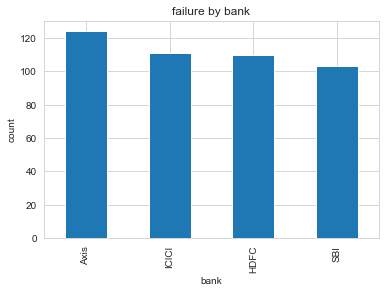

In [16]:
df[df['status']=='failed']['bank'].value_counts().plot(kind='bar')
plt.title("failure by bank")
plt.xlabel("bank")
plt.ylabel("count")
plt.show()

### Hour vs Failures 



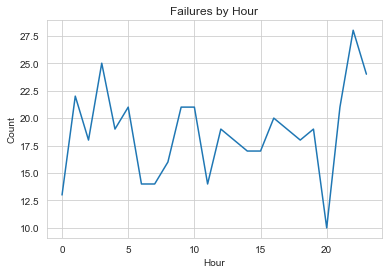

In [20]:
df[df['status']=='failed']['hour'].value_counts().sort_index().plot(kind='line')
plt.title("Failures by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

### Error Reasons 

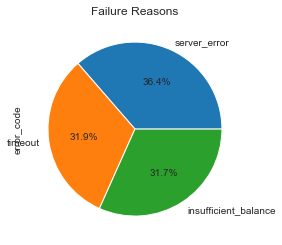

In [21]:
df[df['status']=='failed']['error_code'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Failure Reasons")
plt.show()

### Peak vs Non-Peak

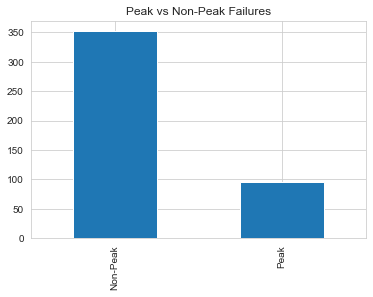

In [22]:
df['peak_type'] = df['hour'].apply(lambda x: 'Peak' if 18 <= x <= 22 else 'Non-Peak')

df[df['status']=='failed']['peak_type'].value_counts().plot(kind='bar')
plt.title("Peak vs Non-Peak Failures")
plt.show()

## Conclusion:


#### UPI transaction failures are mainly concentrated in specific banks and peak hours, with timeout errors being the primary cause. Improving system performance during high-traffic periods and optimizing bank integrations can significantly reduce failures.